In [1]:
import sys

sys.path.insert(1, '../ML_pipeline')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.model_selection import GroupKFold, StratifiedKFold

### Load in feature data and create an array of hand-selected features

In [2]:
full_df = pd.read_csv('features.csv')

device_list = ['hand',
               'chest',
               'ankle']

axes_list = ['x',
             'y',
             'z',
             'amp']

sensor_list = ['acc16',
               'gyro']

stat_list = ['mean',
             'hmean',
             'std',
             'max',
             'min',
             'median',
             'p2p',
             'mad',
             'iqr',
             'sum_abs',
             'mean_energy',
             'skew',
             'kurtosis']

feature_list = []

for stat in stat_list:
    feature_list.append('heart_rate_'+stat)

for device in device_list:
    for sensor in sensor_list:
        
        for axis in axes_list:
            for stat in stat_list:
                label = '_'.join([device,sensor,axis,stat])
                feature_list.append(label)
        
        for pair in ['xy','xz','yz']:
            label = '_'.join([device,sensor,'corr',pair])


X = full_df[feature_list]
y = full_df['activity_id']
groups = full_df['interval_id']

In [3]:
# creates new activity dataframe based on input groups
# group_dict is a dictionary where keys are the desired group labels and values are the lists of activity ids in the new group
def group_activities(y,group_dict):
    y_new = y.copy(deep=True)

    for group in group_dict.keys():
        for id in group_dict[group]:
            y_new.replace(to_replace=id,value=group,inplace=True)

    return y_new

name_map = {
        0: 'Transient/Break', 1: 'Lying down', 2: 'Sitting', 3: 'Standing', 
        4: 'Walking', 5: 'Running', 6: 'Cycling', 7: 'Nordic walking', 
        9: 'Watching TV', 10: 'Computer work', 11: 'Car driving', 
        12: 'Ascending stairs', 13: 'Descending stairs', 16: 'Vacuum cleaning', 
        17: 'Ironing', 18: 'Folding laundry', 19: 'House cleaning', 
        20: 'Playing soccer', 24: 'Rope jumping'
    }

'Similar activities grouping:'
sim_groups = {1:[1,2], #lying, sitting
              4:[4,7], #walking, nordic walking
              16:[16,17] #vacuum cleaning, ironing
              }
name_map_sim = {
    1: "Resting",
    3: "Standing",
    4: "Walking",
    5: "Running",
    6: "Cycling",
    9: "Watching TV",
    10: "Computer Work",
    11: "Car Driving",
    12: "Ascending \nStairs",
    13: "Descending \nStairs",
    16: "House Work",
    18: "Folding Laundry",
    19: "House Cleaning",
    20: "Playing Soccer",
    24: "Rope \nJumping",
}

y_sim = group_activities(y,sim_groups)

'Low/medium/high activity grouping:'
LMH_groups = {101:[1,2,3], #lying, sitting, standing
              102:[4,7,12,13,16,17], #walking, nordic walking, ascending stairs, descending stairs, vacuum cleaning, ironing
              103:[5,6,24] #running, cycling, rope jumping
              } 

name_map_LMH = {
    101: "Low \nActivity",
    102: "Medium \nActivity",
    103: "High \nActivity",
}

y_LMH = group_activities(y,LMH_groups)

### Loop through sets of hyperparameters to train the model on, print out accuracies

In [4]:
print(f"X shape: {X.shape}")
print("Class counts:")
print(y.value_counts().sort_index())

def run_KNN(y,n_neighbors=5,weights='uniform',print_metrics=True):

    knn_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
        (
            "KNN",
            KNeighborsClassifier(
                n_neighbors=n_neighbors,
                weights=weights,
                n_jobs=-1,
            ),
        ),
    ])

    fold_rows = []
    all_true = []
    all_pred = []

    labels_sorted = np.sort(y.unique())
    gkf = GroupKFold(n_splits=5)
    #gkf = StratifiedKFold(n_splits=5)
    

    for fold_idx, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=groups), start=1):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        knn_pipeline.fit(X_train, y_train)
        y_pred = knn_pipeline.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
            y_test,
            y_pred,
            average="macro",
            zero_division=0,
        )

        fold_rows.append(
            {
                "fold": fold_idx,
                "accuracy": acc,
                "macro_precision": prec_macro,
                "macro_recall": rec_macro,
                "macro_f1": f1_macro,
                "n_test": len(test_idx),
            }
        )

        all_true.append(y_test.to_numpy())
        all_pred.append(y_pred)

        # print(
        #     f"Fold {fold_idx}: "
        #     f"acc={acc:.4f}, macro_f1={f1_macro:.4f}, n_test={len(test_idx)}"
        # )

    cv_metrics = pd.DataFrame(fold_rows)
    #print("\n5-fold metrics:")
    metrics_5f = pd.DataFrame(fold_rows)

    #print("\nAverage performance (5-fold):")
    avgPerf_5f = cv_metrics[["accuracy", "macro_precision", "macro_recall", "macro_f1"]].mean().to_frame("mean").join(
            cv_metrics[["accuracy", "macro_precision", "macro_recall", "macro_f1"]]
            .std(ddof=1)
            .to_frame("std")
        )

    y_true_all = np.concatenate(all_true)
    y_pred_all = np.concatenate(all_pred)

    #print("\nClassification report (all fold predictions combined):")
    report = classification_report(y_true_all, y_pred_all, labels=labels_sorted, zero_division=0)

    if print_metrics:
        print("\n5-fold metrics:")
        print(metrics_5f)
        print("\nAverage performance (5-fold):")
        print(avgPerf_5f)
        print("\nClassification report (all fold predictions combined):")
        print(report)

    return y_true_all,y_pred_all,y_test,y_pred,labels_sorted,metrics_5f,avgPerf_5f,report


#loop through hyperparameters
k_vals = [5,10,20,30,50]
weight_vals = ['uniform','distance']

metrics5f_dict = {}
report_dict = {}
avgPerf5f_dict = {}

for weights in weight_vals:
    for k in k_vals:
        y_true_all,y_pred_all,y_test,y_pred,labels_sorted,metrics_5f,avgPerf_5f,report = run_KNN(y,n_neighbors=k,weights=weights,print_metrics=False)

        label = weights + '-' + str(k)
        metrics5f_dict[label] = metrics_5f
        report_dict[label] = report
        avgPerf5f_dict[label] = avgPerf_5f


# print(acc_dict)
# print(report_dict['uniform-5'])
# print(cm_dict['uniform-5'])

X shape: (18103, 325)
Class counts:
activity_id
1.0     1829
2.0     1757
3.0     1802
4.0     2296
5.0      910
6.0     1562
7.0     1798
12.0     980
13.0     843
16.0    1657
17.0    2291
24.0     378
Name: count, dtype: int64


### Make the 2D projection of activities

In [5]:
for key in report_dict.keys():
    print('--------------------------------------------------------')
    print(key)
    print(report_dict[key])

--------------------------------------------------------
uniform-5
              precision    recall  f1-score   support

         1.0       0.99      0.95      0.97      1829
         2.0       0.73      0.75      0.74      1757
         3.0       0.72      0.76      0.74      1802
         4.0       0.56      0.60      0.58      2296
         5.0       0.96      0.96      0.96       910
         6.0       0.96      0.98      0.97      1562
         7.0       0.46      0.43      0.45      1798
        12.0       0.93      0.96      0.94       980
        13.0       0.95      0.93      0.94       843
        16.0       0.87      0.75      0.81      1657
        17.0       0.77      0.81      0.79      2291
        24.0       0.99      0.82      0.90       378

    accuracy                           0.78     18103
   macro avg       0.83      0.81      0.82     18103
weighted avg       0.78      0.78      0.78     18103

--------------------------------------------------------
uniform-1

In [6]:
y_true_all,y_pred_all,y_test,y_pred,labels,temp,temp,temp = run_KNN(y,n_neighbors=20,weights='uniform')


5-fold metrics:
   fold  accuracy  macro_precision  macro_recall  macro_f1  n_test
0     1  0.842585         0.793026      0.791901  0.785964    3621
1     2  0.773418         0.766742      0.711250  0.696694    3619
2     3  0.772589         0.772176      0.774208  0.765741    3619
3     4  0.799060         0.764680      0.751524  0.747817    3618
4     5  0.753447         0.661342      0.638178  0.646329    3626

Average performance (5-fold):
                     mean       std
accuracy         0.788220  0.034444
macro_precision  0.751593  0.051688
macro_recall     0.733412  0.061184
macro_f1         0.728509  0.056626

Classification report (all fold predictions combined):
              precision    recall  f1-score   support

         1.0       1.00      0.94      0.97      1829
         2.0       0.75      0.78      0.76      1757
         3.0       0.77      0.75      0.76      1802
         4.0       0.57      0.63      0.60      2296
         5.0       0.96      0.97      0.96

In [7]:
y_true_all,y_pred_all,y_test,y_pred,labels,temp,temp,temp = run_KNN(y,n_neighbors=20,weights='uniform')


5-fold metrics:
   fold  accuracy  macro_precision  macro_recall  macro_f1  n_test
0     1  0.842585         0.793026      0.791901  0.785964    3621
1     2  0.773418         0.766742      0.711250  0.696694    3619
2     3  0.772589         0.772176      0.774208  0.765741    3619
3     4  0.799060         0.764680      0.751524  0.747817    3618
4     5  0.753447         0.661342      0.638178  0.646329    3626

Average performance (5-fold):
                     mean       std
accuracy         0.788220  0.034444
macro_precision  0.751593  0.051688
macro_recall     0.733412  0.061184
macro_f1         0.728509  0.056626

Classification report (all fold predictions combined):
              precision    recall  f1-score   support

         1.0       1.00      0.94      0.97      1829
         2.0       0.75      0.78      0.76      1757
         3.0       0.77      0.75      0.76      1802
         4.0       0.57      0.63      0.60      2296
         5.0       0.96      0.97      0.96

In [8]:
y_true_all_sim,y_pred_all_sim,y_test_sim,y_pred_sim,labels_sim,temp,temp,temp = run_KNN(y_sim,n_neighbors=20,weights='uniform')


5-fold metrics:
   fold  accuracy  macro_precision  macro_recall  macro_f1  n_test
0     1  0.881524         0.888265      0.914233  0.894213    3621
1     2  0.905499         0.813558      0.771764  0.786830    3619
2     3  0.919591         0.952314      0.924055  0.934349    3619
3     4  0.881703         0.876938      0.863731  0.867476    3618
4     5  0.947876         0.849816      0.809094  0.826668    3626

Average performance (5-fold):
                     mean       std
accuracy         0.907239  0.027930
macro_precision  0.876178  0.051380
macro_recall     0.856575  0.065910
macro_f1         0.861907  0.057447

Classification report (all fold predictions combined):
              precision    recall  f1-score   support

         1.0       0.87      0.87      0.87      3586
         3.0       0.78      0.74      0.76      1802
         4.0       0.97      0.99      0.98      4094
         5.0       0.96      0.97      0.96       910
         6.0       0.96      0.98      0.97

In [9]:
y_true_all_LMH,y_pred_all_LMH,y_test_LMH,y_pred_LMH,labels_LMH,temp,temp,temp = run_KNN(y_LMH,n_neighbors=20,weights='uniform')


5-fold metrics:
   fold  accuracy  macro_precision  macro_recall  macro_f1  n_test
0     1  0.909417         0.886347      0.932836  0.902741    3621
1     2  0.956342         0.964331      0.943698  0.953222    3619
2     3  0.971539         0.978800      0.971844  0.975126    3619
3     4  0.928966         0.935698      0.917961  0.926402    3618
4     5  0.969939         0.979753      0.968245  0.973157    3626

Average performance (5-fold):
                     mean       std
accuracy         0.947241  0.027171
macro_precision  0.948986  0.039278
macro_recall     0.946917  0.023040
macro_f1         0.946129  0.031198

Classification report (all fold predictions combined):
              precision    recall  f1-score   support

       101.0       0.93      0.92      0.93      5388
       102.0       0.95      0.96      0.95      9865
       103.0       0.98      0.96      0.97      2850

    accuracy                           0.95     18103
   macro avg       0.95      0.95      0.9

In [10]:
def plot_cm(y_true_all,y_pred_all,labels_sorted,activity_name_map,name):

    # Activity labels after class-combination:
    # 2 -> 1 (Resting), 7 -> 4 (Walking), 17 -> 16 (House Work)

    # Use combined-category names in confusion matrix axes.
    # activity_name_map = {
    #     0: 'Transient/Break', 1: 'Lying down', 2: 'Sitting', 3: 'Standing', 
    #     4: 'Walking', 5: 'Running', 6: 'Cycling', 7: 'Nordic walking', 
    #     9: 'Watching TV', 10: 'Computer work', 11: 'Car driving', 
    #     12: 'Ascending stairs', 13: 'Descending stairs', 16: 'Vacuum cleaning', 
    #     17: 'Ironing', 18: 'Folding laundry', 19: 'House cleaning', 
    #     20: 'Playing soccer', 24: 'Rope jumping'
    # }

    def _label_with_prefix(activity_id, prefix):
        name = activity_name_map.get(int(activity_id), f"ID{int(activity_id)}")
        return f"{name}"

    cm = pd.DataFrame(
        confusion_matrix(y_true_all, y_pred_all, labels=labels_sorted),
        index=[_label_with_prefix(lbl, "T") for lbl in labels_sorted],
        columns=[_label_with_prefix(lbl, "P") for lbl in labels_sorted],
    )

    print("\nConfusion matrix (5-fold pooled predictions):")
    print(cm)




    # Pretty, colorized confusion matrix saved as PNG.
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(cm.values, cmap="Blues")

    ax.set_xticks(np.arange(len(cm.columns)))
    ax.set_yticks(np.arange(len(cm.index)))
    ax.set_xticklabels(cm.columns, rotation=45, ha="right")
    ax.set_yticklabels(cm.index)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title("KNN Model group K splitting Confusion Matrix ("+name+")")

    # Annotate each cell with count value.
    threshold = cm.values.max() / 2 if cm.values.size else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = cm.iat[i, j]
            color = "white" if value > threshold else "black"
            ax.text(j, i, str(value), ha="center", va="center", color=color, fontsize=9)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Count")
    fig.tight_layout()

    output_png = "KNN_group_K_split_confusion_matrix_"+name.split(' ')[0]+".png"
    fig.savefig(output_png, dpi=200, bbox_inches="tight")
    print(f"\nSaved confusion group K split matrix PNG: {output_png}")
    plt.show()

def plot_cm_test(y_test,y_pred,labels_sorted,activity_name_map,name):


    def _label_with_prefix(activity_id, prefix):
        name = activity_name_map.get(int(activity_id), f"ID{int(activity_id)}")
        return f"{name}"

    cm = pd.DataFrame(
        confusion_matrix(y_test, y_pred, labels=labels_sorted),
        index=[_label_with_prefix(lbl, "T") for lbl in labels_sorted],
        columns=[_label_with_prefix(lbl, "P") for lbl in labels_sorted],
    )

    print("\nConfusion matrix (test set):")
    print(cm)




    # Pretty, colorized confusion matrix saved as PNG.
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(cm.values, cmap="Blues")

    ax.set_xticks(np.arange(len(cm.columns)))
    ax.set_yticks(np.arange(len(cm.index)))
    ax.set_xticklabels(cm.columns, rotation=45, ha="right")
    ax.set_yticklabels(cm.index)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title("KNN Confusion Matrix ("+name+")")

    # Annotate each cell with count value.
    threshold = cm.values.max() / 2 if cm.values.size else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = cm.iat[i, j]
            color = "white" if value > threshold else "black"
            ax.text(j, i, str(value), ha="center", va="center", color=color, fontsize=9)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Count")
    fig.tight_layout()

    output_png = "KNN_confusion_matrix_"+name.split(' ')[0]+".png"
    fig.savefig(output_png, dpi=200, bbox_inches="tight")
    print(f"\nSaved confusion matrix PNG: {output_png}")
    plt.show()


Confusion matrix (5-fold pooled predictions):
                   Lying down  Sitting  Standing  Walking  Running  Cycling  \
Lying down               1725       10         9        0        0        1   
Sitting                     2     1365       225        0        0        5   
Standing                    0      265      1357        0        0        0   
Walking                     0        0         0     1445        0        0   
Running                     0        1         3        8      881        0   
Cycling                     0        3         2        0        0     1536   
Nordic walking              0        2         2      988        1        0   
Ascending stairs            0        0         0       48        1        0   
Descending stairs           0        0         3       40        1        1   
Vacuum cleaning             0        4        35       15        0       58   
Ironing                     1      178       117        2        0        5   
Rope 

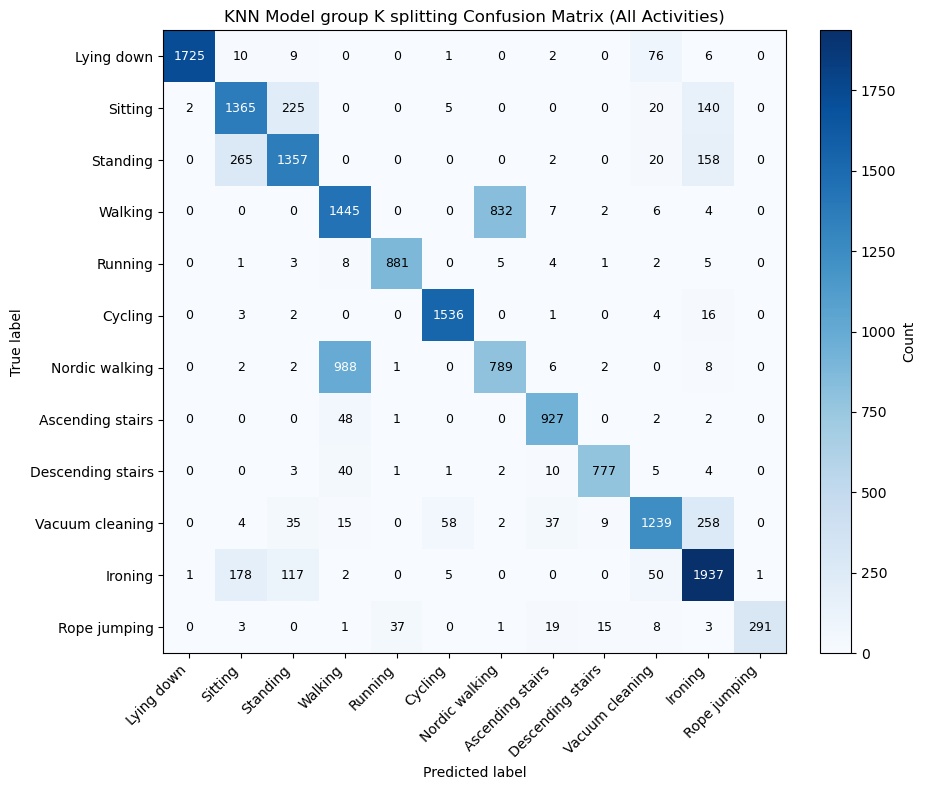


Confusion matrix (test set):
                   Lying down  Sitting  Standing  Walking  Running  Cycling  \
Lying down                844        4         4        0        0        1   
Sitting                     0      104         1        0        0        0   
Standing                    0       30       139        0        0        0   
Walking                     0        0         0      635        0        0   
Running                     0        0         0        1      231        0   
Cycling                     0        0         0        0        0      430   
Nordic walking              0        0         0      269        0        0   
Ascending stairs            0        0         0        3        1        0   
Descending stairs           0        0         0       11        0        0   
Vacuum cleaning             0        0         0        0        0        0   
Ironing                     0        0         0        0        0        0   
Rope jumping          

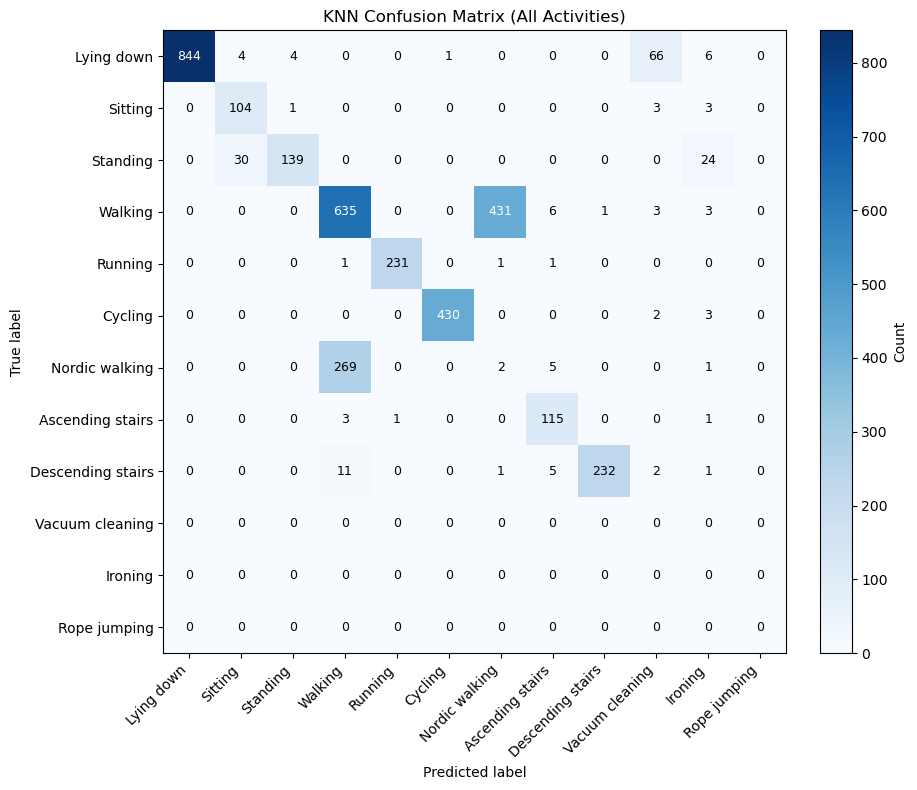

In [11]:
plot_cm(y_true_all,y_pred_all,labels,name_map,name='All Activities')
plot_cm_test(y_test,y_pred,labels,name_map,name='All Activities')


Confusion matrix (5-fold pooled predictions):
                     Resting  Standing  Walking  Running  Cycling  \
Resting                 3106       228        0        0        5   
Standing                 268      1340        0        0        0   
Walking                    2         2     4060        0        0   
Running                    1         3       14      880        0   
Cycling                    3         2        0        0     1535   
Ascending \nStairs         0         0       49        0        0   
Descending \nStairs        0         3       47        0        0   
House Work               183       136       18        0       56   
Rope \nJumping             3         0        2       37        0   

                     Ascending \nStairs  Descending \nStairs  House Work  \
Resting                               2                    0         245   
Standing                              2                    0         192   
Walking                           

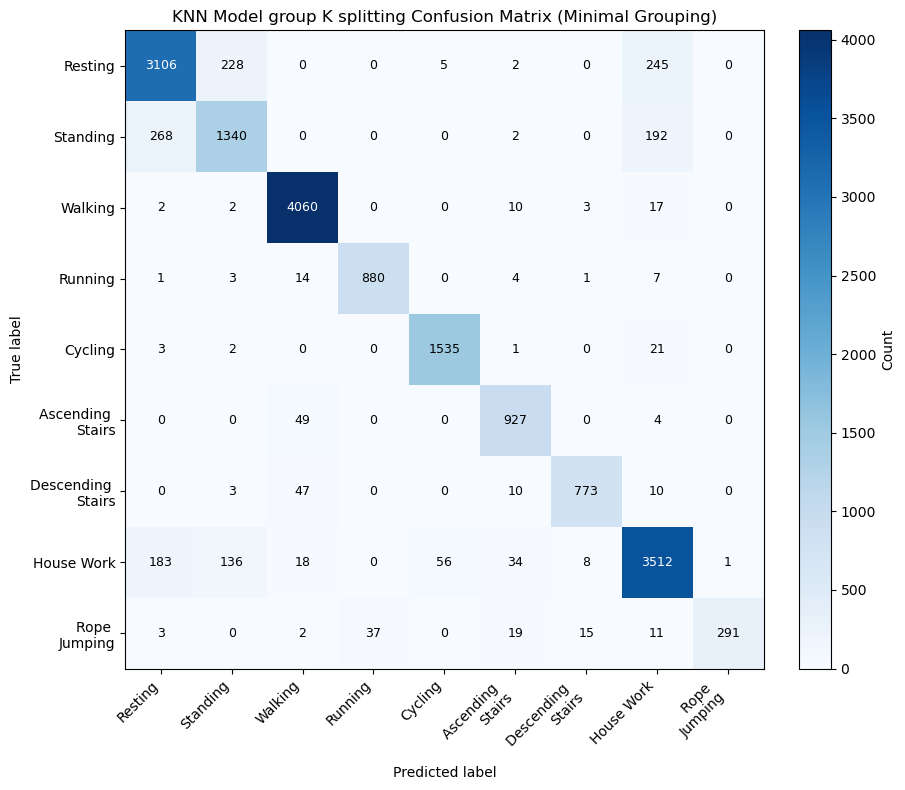


Confusion matrix (test set):
                     Resting  Standing  Walking  Running  Cycling  \
Resting                  953         5        0        0        1   
Standing                  30       138        0        0        0   
Walking                    0         0     1339        0        0   
Running                    0         0        3      230        0   
Cycling                    0         0        0        0      430   
Ascending \nStairs         0         0        4        0        0   
Descending \nStairs        0         0       12        0        0   
House Work                 0         0        0        0        0   
Rope \nJumping             0         0        0        0        0   

                     Ascending \nStairs  Descending \nStairs  House Work  \
Resting                               0                    0          77   
Standing                              0                    0          25   
Walking                               9            

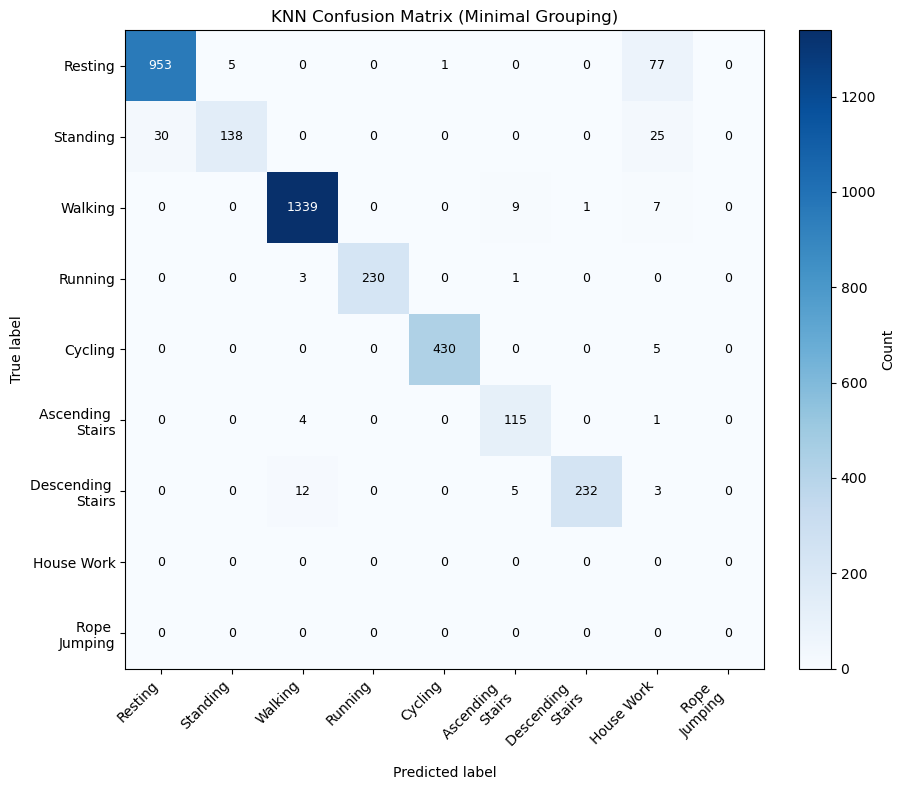

In [12]:
plot_cm(y_true_all_sim,y_pred_all_sim,labels_sim,name_map_sim,name='Minimal Grouping')
plot_cm_test(y_test_sim,y_pred_sim,labels_sim,name_map_sim,name='Minimal Grouping')


Confusion matrix (5-fold pooled predictions):
                   Low \nActivity  Medium \nActivity  High \nActivity
Low \nActivity               4981                402                5
Medium \nActivity             378               9441               46
High \nActivity                12                112             2726

Saved confusion group K split matrix PNG: KNN_group_K_split_confusion_matrix_LMH.png


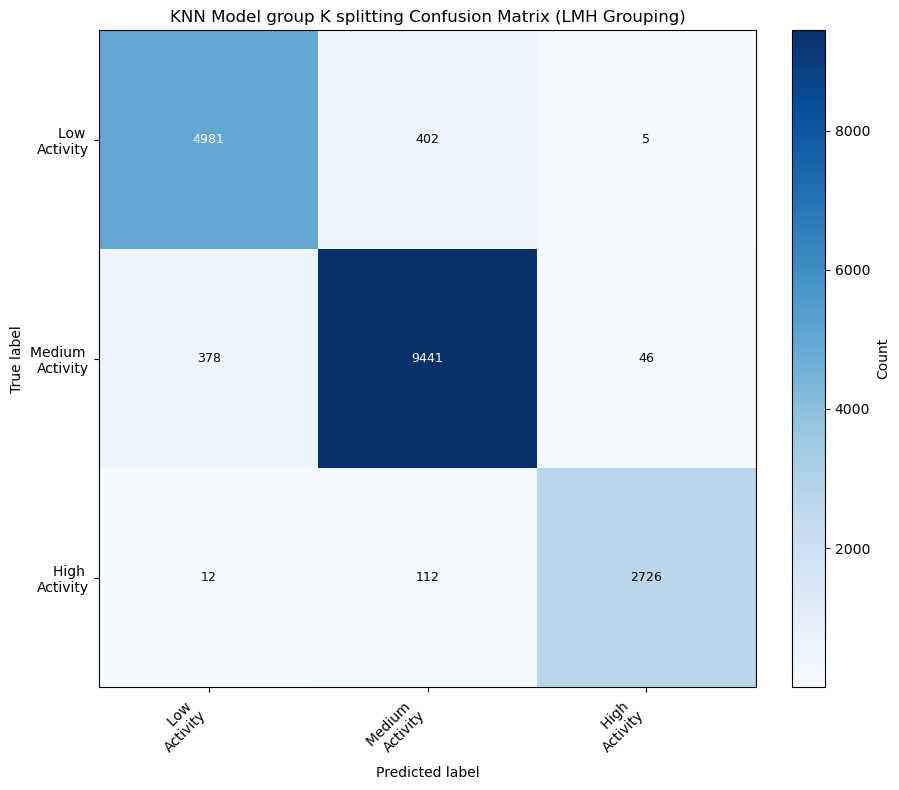


Confusion matrix (test set):
                   Low \nActivity  Medium \nActivity  High \nActivity
Low \nActivity               1131                 97                1
Medium \nActivity               1               1727                0
High \nActivity                 0                 10              659

Saved confusion matrix PNG: KNN_confusion_matrix_LMH_grouping.png


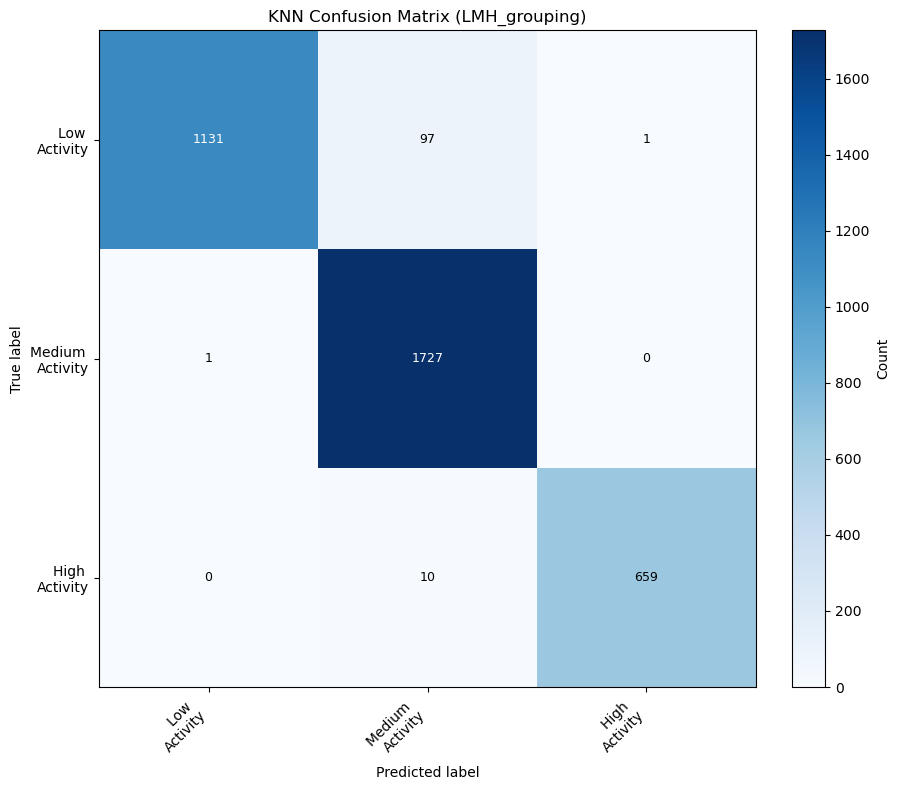

In [13]:
plot_cm(y_true_all_LMH,y_pred_all_LMH,labels_LMH,name_map_LMH,name='LMH Grouping')
plot_cm_test(y_test_LMH,y_pred_LMH,labels_LMH,name_map_LMH,name='LMH_grouping')